In [1]:
import fdfi
print('FDFI version:', fdfi.__version__)

FDFI version: 0.0.9


# Quickstart: FDFI in 5 Minutes

This tutorial introduces the basics of FDFI (Flow-Disentangled Feature Importance). By the end, you'll be able to:

1. Create an explainer for any model
2. Compute feature importance
3. Interpret the results
4. Get confidence intervals

## Setup

First, let's import the necessary libraries:

In [2]:
import numpy as np
from fdfi.explainers import OTExplainer
from fdfi.plots import confidence_interval_plot, summary_bar

# Set random seed for reproducibility
np.random.seed(42)

## Create a Simple Model

Let's create a simple model where we know the true feature importance. Features 0 and 1 are important, the rest are noise:

In [3]:
def model(X):
    """Simple model: y = x0 + 2*x1 + 0.5*x2"""
    return X[:, 0] + 2 * X[:, 1] + 0.5 * X[:, 2]

# Create training data (used as background distribution)
n_samples = 200
n_features = 10
X_train = np.random.randn(n_samples, n_features)

# Create test data to explain
X_test = np.random.randn(100, n_features)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Model predictions for test data: {model(X_test)[:5]}")

Training data shape: (200, 10)
Test data shape: (100, 10)
Model predictions for test data: [-1.36042558 -3.5175806   1.2950158  -0.90179092 -1.77532221]


## Create an Explainer

The `OTExplainer` uses Gaussian optimal transport to compute feature importance:

In [4]:
# Create the explainer
explainer = OTExplainer(
    model,              # The model to explain
    data=X_train,       # Background data
    nsamples=50,        # Monte Carlo samples per feature
)

print("Explainer created!")

Explainer created!


## Compute Feature Importance

Call the explainer on test data to get feature importance:

In [5]:
# Compute feature importance
results = explainer(X_test)

# Print the results
print("Feature Importance (phi_X):")
for i, phi in enumerate(results["phi_X"]):
    print(f"  Feature {i}: {phi:.4f}")

Feature Importance (phi_X):
  Feature 0: 0.7829
  Feature 1: 4.9322
  Feature 2: 0.2430
  Feature 3: 0.0113
  Feature 4: 0.0224
  Feature 5: 0.0095
  Feature 6: 0.0159
  Feature 7: 0.0033
  Feature 8: 0.0010
  Feature 9: 0.0369


## Visualize Feature Importance

Use `summary_bar` immediately after `results = explainer(X_test)` to inspect global scores and standard errors.

,feature,phi,se
0,X1,4.932162,0.707248
1,X0,0.782885,0.099568
2,X2,0.243048,0.032722
3,X9,0.036922,0.003583
4,X4,0.022351,0.002071


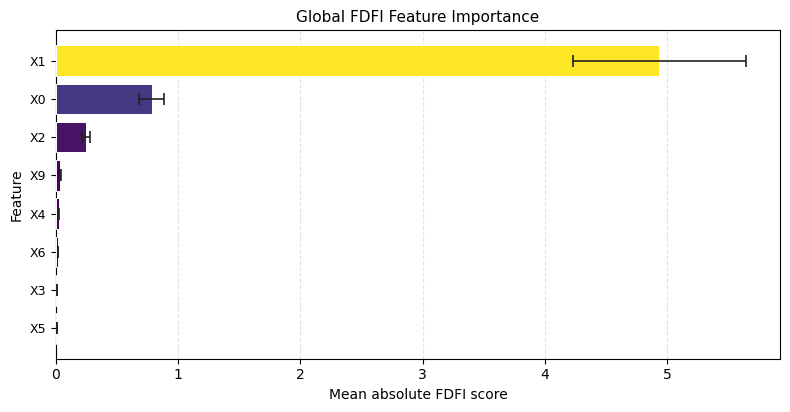

In [6]:
feature_names = [f"X{i}" for i in range(n_features)]

fig, ax, importance_table = summary_bar(
    results["phi_X"],
    results["se_X"],
    feature_names,
    max_display=8,
    show=False,
)
importance_table.head()

## Interpret the Results

The `results` dictionary contains:
- `phi_X`: Feature importance in the original X-space
- `phi_Z`: Feature importance in the disentangled Z-space
- `se_X`, `se_Z`: Standard errors for uncertainty quantification

Higher values indicate more important features. Since our model uses `x0 + 2*x1 + 0.5*x2`, we expect Features 0, 1, and 2 to have the highest importance.

In [7]:
# Sort features by importance
importance = results["phi_X"]
sorted_idx = np.argsort(importance)[::-1]

print("Features ranked by importance:")
for rank, idx in enumerate(sorted_idx):
    print(f"  Rank {rank+1}: Feature {idx} (importance = {importance[idx]:.4f})")

Features ranked by importance:
  Rank 1: Feature 1 (importance = 4.9322)
  Rank 2: Feature 0 (importance = 0.7829)
  Rank 3: Feature 2 (importance = 0.2430)
  Rank 4: Feature 9 (importance = 0.0369)
  Rank 5: Feature 4 (importance = 0.0224)
  Rank 6: Feature 6 (importance = 0.0159)
  Rank 7: Feature 3 (importance = 0.0113)
  Rank 8: Feature 5 (importance = 0.0095)
  Rank 9: Feature 7 (importance = 0.0033)
  Rank 10: Feature 8 (importance = 0.0010)


## Get Confidence Intervals

FDFI provides statistical inference via `conf_int()`:

In [8]:
# Compute confidence intervals
ci = explainer.conf_int(
    alpha=0.05,           # 95% confidence level
    target="X",           # Use X-space importance
    alternative="greater" # Test if importance > 0
)

print("\nConfidence Intervals (95%, one-sided):")
print("-" * 70)
print(f"{'Feature':>8} {'Estimate':>10} {'SE':>10} {'Z-score':>10} {'Rank':>6} {'P-value':>10}")
print("-" * 70)
for i in range(n_features):
    sig = "*" if ci["reject_null"][i] else ""
    print(f"{i:>8} {ci['score'][i]:>10.4f} {ci['se'][i]:>10.4f} "
          f"{ci['zscore'][i]:>10.4f} {ci['ranking'][i]:>6} {ci['pvalue'][i]:>10.4f} {sig}")

print("\n* = significant at alpha=0.05")
print("\nNote: 'zscore' = (score - margin) / se, 'ranking' = rank by descending z-score.")



Confidence Intervals (95%, one-sided):
----------------------------------------------------------------------
 Feature   Estimate         SE    Z-score   Rank    P-value
----------------------------------------------------------------------
       0     0.7829     0.1201     6.2117      2     0.0000 *
       1     4.9322     0.7104     6.8906      1     0.0000 *
       2     0.2430     0.0747     2.7597      3     0.0029 *
       3     0.0113     0.0671    -0.3810      7     0.6484 
       4     0.0224     0.0672    -0.2169      5     0.5859 
       5     0.0095     0.0672    -0.4088      8     0.6587 
       6     0.0159     0.0672    -0.3128      6     0.6228 
       7     0.0033     0.0671    -0.5007      9     0.6917 
       8     0.0010     0.0671    -0.5350     10     0.7037 
       9     0.0369     0.0672     0.0000      4     0.5000 

* = significant at alpha=0.05

Note: 'zscore' = (score - margin) / se, 'ranking' = rank by descending z-score.


(<Figure size 800x422 with 1 Axes>,
 <Axes: title={'center': 'FDFI Confidence Intervals  (one-sided)'}, xlabel='FDFI score with confidence interval  [H₁: φ > margin, one-sided]'>)

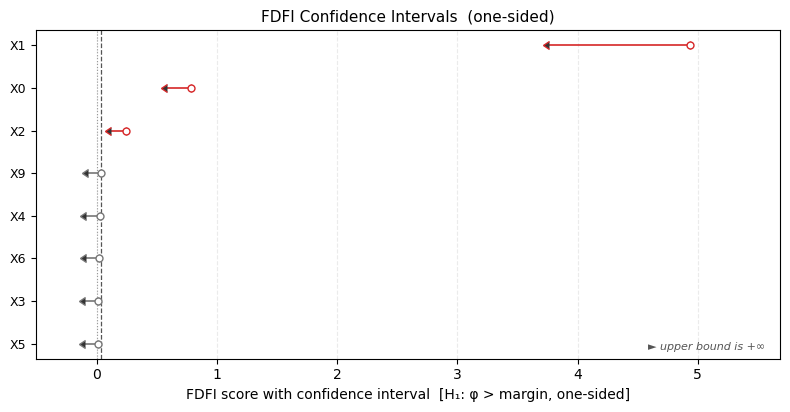

In [9]:
confidence_interval_plot(
    ci,
    feature_names=feature_names,
    max_display=8,
    show=False,
)

## View Summary

Use the built-in `summary()` method for a formatted output:

In [10]:
# Print formatted summary
explainer.summary(alpha=0.05, alternative="greater")

Feature Importance Results
Method: OTExplainer
Number of units: 10
Significance level: 0.05
Alternative: greater
Margin method: gap
Practical margin: 0.0369
------------------------------------------------------------------------------
        Feature   Estimate    Std Err   CI Lower   CI Upper    P-value   Sig
------------------------------------------------------------------------------
              0     0.7829     0.1201     0.5854        inf     0.0000   ***
              1     4.9322     0.7104     3.7636        inf     0.0000   ***
              2     0.2430     0.0747     0.1202        inf     0.0029   ***
              3     0.0113     0.0671    -0.0991        inf     0.6484      
              4     0.0224     0.0672    -0.0881        inf     0.5859      
              5     0.0095     0.0672    -0.1010        inf     0.6587      
              6     0.0159     0.0672    -0.0946        inf     0.6228      
              7     0.0033     0.0671    -0.1071        inf     0.691

"==============================================================================\nFeature Importance Results\n==============================================================================\nMethod: OTExplainer\nNumber of units: 10\nSignificance level: 0.05\nAlternative: greater\nMargin method: gap\nPractical margin: 0.0369\n------------------------------------------------------------------------------\n        Feature   Estimate    Std Err   CI Lower   CI Upper    P-value   Sig\n------------------------------------------------------------------------------\n              0     0.7829     0.1201     0.5854        inf     0.0000   ***\n              1     4.9322     0.7104     3.7636        inf     0.0000   ***\n              2     0.2430     0.0747     0.1202        inf     0.0029   ***\n              3     0.0113     0.0671    -0.0991        inf     0.6484      \n              4     0.0224     0.0672    -0.0881        inf     0.5859      \n              5     0.0095     0.0672    -0.101

## Next Steps

Now that you've learned the basics, check out these tutorials:

- **OT Explainer Deep Dive**: Learn more about the Gaussian OT method
- **EOT Explainer**: Entropic OT for non-Gaussian data
- **Confidence Intervals**: Advanced statistical inference